In [14]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o-mini",temperature=0.01)
model.invoke('안녕하세요')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_43b64008fd', 'id': 'chatcmpl-DZXaSO1k2WseOq0swtJowsGoLZ7r8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd316-7623-7230-8f3b-5c41ef68b4d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [15]:
from typing import Annotated # Annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict) :
    """
    State 클래스는 TypeDict를 상속받습니다.
    
    속성:
        messages (Annotated[list[str],add_messages]): 메시지들은 "list" 타입을 가집니다.
        'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다.)
    """ 
    messages: Annotated[list[str], add_messages]

graph_builder = StateGraph(State)

In [16]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
import bs4
from langchain_community.document_loaders import WebBaseLoader

@tool
def get_current_time(timezone:str,location:str)->str:
    """현재 시각을 반환하는 함수"""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재 시각 {now}'
        
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query:str,search_period:str="m")->str:
    """
    웹 검색을 수행하는 함수
        Args: 
            query (str):    검색어
            search_period (str):    검색 기간 (e.g., "w" for past week(default), "m" for past month, "y" for fast year, "d" for past day)
        
        returns:
            str:    검색 결과    
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region = "kr-kr"
        time=search_period
    )
    
    print('\n--------WEB SEARCH--------')
    print(query)
    print(search_period)
    
    search = DuckDuckGoSearchResults(
        api_wrapper = wrapper,
        #source="new",
        results_separator = ';\n'
    )
    
    searched = search.invoke(query)
    for i , result in enumerate(searched.split(';\n')):
        print(f'{i+1},{result}')
        
    return searched

tools= [get_current_time,get_web_search]

In [17]:
tools[0].invoke({"timezone":"Asia/Seoul","location":"서울"})

'Asia/Seoul (서울) 현재 시각 2026-04-28 16:55:59'

In [18]:
tools[1].invoke({"query":"파이썬","search_period":"m"})


--------WEB SEARCH--------
파이썬
m
1,snippet: 1 week ago - )은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, '인터프리터를 사용하는 객체지향 언어'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬
2,snippet: 6 days ago - Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, "plain English" naming, an extensive ("batteries-included") standard library, and garbage collection., title: Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language)
3,snippet: 6 days ago - 즉, 같은 것을 하는 다른 방법이 있는지 여부 자체가 중요한 것이 아닌, 가장 명백한 방법이 존재한다면 파이썬의 정신에 위배되지 않는다는 것이다.[5] 파이썬의 디자인 철학에 맞는 코드를 짜는 것을 파이써닉(pythonic)이라고 부른다., title: Python - 파이썬, link: https://namu.wiki/w/Python
4,snippet: 2 weeks ago - 파이썬의 `while` 반복문을 제대로 이해하고 활용하기 위해선 몇 가지 준비가 필요해요. 이 글에서는 `while` 문을 처음 접하는 분부터, 무한루프의 함정을 피하고 싶

'snippet: 1 week ago - )은 1991년 네덜란드계 소프트웨어 엔지니어인 귀도 반 로섬이 발표한 고급 프로그래밍 언어로, \'인터프리터를 사용하는 객체지향 언어\'이자 플랫폼에 독립적인, 동적 타이핑(dynamically typed) 대화형 언어다., title: 파이썬 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/파이썬;\nsnippet: 6 days ago - Python is a high-level, general-purpose programming language that emphasizes code readability, simplicity, and ease-of-writing with the use of significant indentation, "plain English" naming, an extensive ("batteries-included") standard library, and garbage collection., title: Python (programming language) - Wikipedia, link: https://en.wikipedia.org/wiki/Python_(programming_language);\nsnippet: 6 days ago - 즉, 같은 것을 하는 다른 방법이 있는지 여부 자체가 중요한 것이 아닌, 가장 명백한 방법이 존재한다면 파이썬의 정신에 위배되지 않는다는 것이다.[5] 파이썬의 디자인 철학에 맞는 코드를 짜는 것을 파이써닉(pythonic)이라고 부른다., title: Python - 파이썬, link: https://namu.wiki/w/Python;\nsnippet: 2 weeks ago - 파이썬의 `while` 반복문을 제대로 이해하고 활용하기 위해선 몇 가지 준비가 필요해요. 이 글에서는 `while` 문을 처음 접하는 분부터, 무한루프의 함정을 피하고 싶은 분들까지 모두를 위한 내용을 담았답니다., title: 

In [19]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x000001DC2B0BD800>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수\n    Args: \n        query (str):    검색어\n        search_period (str):    검색 기간 (e.g., "w" for past week(default), "m" for past month, "y" for fast year, "d" for past day)\n\n    returns:\n        str:    검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x000001DC245D72E0>


In [ ]:
model_with_tools = model.bind_tools(tools)
# 노드(node): 하나의 작업이자 단계를 의미 
## 노드 생성하기 
### 사용자가 질문하면 답변을 생성하는 generate라는 노드를 가진 랭그래프
### - 기존의 대화 내용에 기반하여 GPT로 답변을 생헝하는 역할
def generate(state:State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수(Args):
        state (State):  현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
    
    반환값:
        dict:   모델이 생성한 응답 메시지를 포함하는 딕셔너리.
                형식은 {"messages":[응답 메세지]}입니다.
    """
    return {"messages":model_with_tools.invoke(state["messages"])}

graph_builder.add_node('generate',generate)




In [21]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict):   도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools:list):   도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs:dict):  입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""
    def __init__(self,tools:list)->None:
        self.tools_by_name = {tool.name:tool for tool in tools}
        
    def __call__(self,inputs:dict):
        if messages:= inputs.get("messages",[]):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call['name']].invoke(
                tool_call['args']
            )    
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                    
                )
            )
        return {"messages":messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)



In [22]:
## 라우터 설정하기
### AI 에이전트가 랭그래프 내에서 스스로 다음 경로를 선택해야 할 때 라우터를 활용
def route_tools(state:State):
    """
    마지막 메세지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝까지 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state,list):
        ai_message = state[-1]
    elif messages := state.get("messages",[]):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다:   {state}")
    if hasattr(ai_message,'tool_calls') and len(ai_message.tool_calls) >0:
        return "tools"
    return END

graph_builder.add_edge(START,'generate')
graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools":"tools",END:END}
)    

graph_builder.add_edge('tools','generate')
graph = graph_builder.compile()

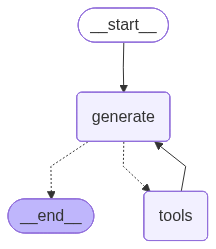

In [23]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [24]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇 시야?")]

gathered = None

for msg, metadata in graph.stream({"messages":inputs},stream_mode="messages"):
    if isinstance(msg,AIMessageChunk):
        print(msg.content, end='')
        
        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg
            
gathered

현재 서울의 시각은 2026년 4월 28일 16시 56분입니다.

AIMessageChunk(content='현재 서울의 시각은 2026년 4월 28일 16시 56분입니다.', additional_kwargs={}, response_metadata={'model_provider': 'openai', 'finish_reason': 'tool_callsstop', 'model_name': 'gpt-4o-mini-2024-07-18gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4ba42b5ccbfp_845d726e38', 'service_tier': 'defaultdefault'}, id='lc_run--019dd316-7e43-7b92-a085-03759de0ad68', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'Asia/Seoul', 'location': '서울'}, 'id': 'call_vG64oUl9yzBnih7TbeqyMtUs', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 376, 'output_tokens': 47, 'total_tokens': 423, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"timezone":"Asia/Seoul","location":"서울"}', 'id': 'call_vG64oUl9yzBnih7TbeqyMtUs', 'index': 0, 'type': 'tool_call_chunk'}], chunk_position='last')

In [25]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "서울 월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다.
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.
- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘.
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐.
- 검색할 리스트를 토대로 재검색해.
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋아.

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성한다.
제목, 부제, 리드문, 본문의 구성으로 작성한다. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
""")]

for msg, metadata in graph.stream({'messages':inputs},stream_mode='messages'):
    if isinstance(msg,AIMessageChunk):
        print(msg.content, end="")
        
        


--------WEB SEARCH--------
서울 월드컵 경기장 잔디 문제
m
1,snippet: 1 week ago - 경기 일정은 2026년 캐나다식 풋볼 리그 시즌과 겹치므로 토론토 아고노츠와 BC 라이온스의 일정 충돌과 홈 경기 손실이 발생할 수 있다 경기 일정은 또한 홈 경기장이 월드컵 경기장 근처에 있는 메이저리그의 캔자스시티 로열스, 필라델피아 필리스, 시애틀 매리너스, 텍사스 레인저스의 일정에도 영향을 미칩니다, title: 2026년 FIFA 월드컵 - 위키백과, 우리 모두의 백과사전, link: https://ko.wikipedia.org/wiki/2026년_FIFA_월드컵
2,snippet: 1 week ago - 서울월드컵경기장의 잔디 ... 외부 공연이나 대관 등으로 경기장 잔디가 손상되는 것도 있지만, 가장 큰 이유는 경기장 관리의 주체가 FC 서울이나 대한축구협회가 아닌 공기업 서울시설공단이기 때문이다.[18] ..., title: 서울월드컵경기장 - 나무위키, link: https://namu.wiki/w/서울월드컵경기장
3,snippet: 2 weeks ago - 규모가 매우 큰 서울월드컵경기장을 대체 공연장으로 쓸 수도 있기는 하지만 이 곳은 잔디 관련 문제로 인해 무대 설치에 제약을 받는다는 큰 단점이 존재한다., title: 서울올림픽주경기장 - 나무위키, link: https://namu.wiki/w/서울올림픽주경기장
4,snippet: 2 weeks ago - 김 어시스턴트는 “축구인이라면 어떤 경기장에서 어떤 스터드를 신어야 하는지는 매우 중요한 문제”라며 “제품을 직접 신어보고 잔디별 차이를 느낄 수 있어 고객들의 만족도가 굉장히 높다”고 했다. ... 나이키 강남 플래그십 스토어의 입구. 유리 외벽 너머 붉은 기운이 시선을 끈다. 사진 제공=나이키 · 서울 강남역 한복판, 유리 외벽 너머로 붉은 기운이 시선을 붙드는 건물이 있다., title: 네 번의 월드컵 품은 ‘축구 성지’ 나이키 강남 | 서울경제, li